In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
import pickle
from src.utils import linear_interpolation, find_closest_indices, adjust_axis_limits

In [6]:
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
#plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams.update({'font.size': 9})
colors = [plt.colormaps['tab20'](i) for i in range(20)]

markersize = 3
styles = dict(
random=dict(linestyle='--', color='gray'),
amsp=dict(color=colors[0], markersize=markersize, marker="v"),
ane=dict(color=colors[1], markersize=markersize, marker="p"),
mmmc=dict(color=colors[2], markersize=markersize, marker="D"),
tla=dict(color=colors[3], markersize=markersize, marker="^"),
pla=dict(color=colors[4], markersize=markersize, marker="o"),
sdc=dict(color=colors[5], markersize=markersize, marker="s"),
aef=dict(color=colors[6], markersize=markersize, marker="*"),
aef_sdc=dict(color=colors[7], markersize=markersize, marker="h"),
oracle=dict(linestyle=':',color='gray'),
idc_true=dict(color=colors[9], marker="*", zorder=-2),
idc_hat=dict(color=colors[10], markersize=markersize+2, marker=".", zorder=-1),
)
styles["pla*"] = styles["pla"]

# MSWML - OOD

In [ ]:
task = 'mswml'
df_coverages_mean = pd.read_pickle(f'df_coverages_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_coverages_std_final_{task}_OOD.pkl')
with open('../mswml/dev_out_gt.pkl', 'rb') as f:
    y = pickle.load(f)
    

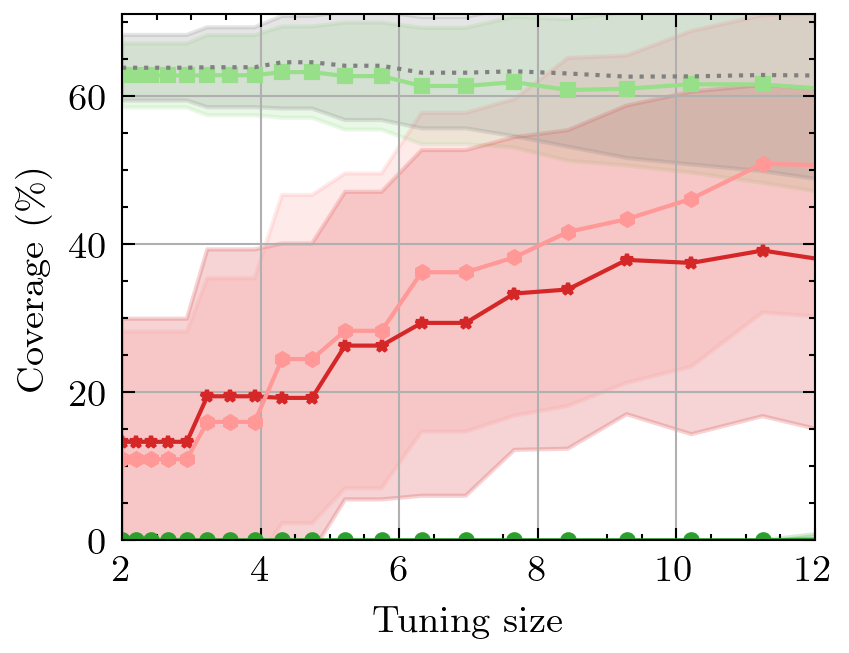

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'mswml'
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams.update({'font.size': 9})
colors = plt.colormaps['tab10']
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)[:-1]
max_tuning_size=int(len(y)/2)

df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_coverages_mean.columns[5:]):
    plt.plot(tuning_size_arrays*len(y), df_coverages_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_coverages_mean[column] - df_std_dev[column], df_coverages_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.xlabel('Tuning size')
plt.ylabel("Coverage (\%)")

#y_min, y_max = adjust_axis_limits(np.mean(df_coverages_mean))

#plt.ylim(y_min, y_max)
plt.ylim(top=np.max(df_coverages_mean)*1.1, bottom=0)

plt.xlim(left = 2,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
# Add legend above the plot
#plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)

# Adjust the plot to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust bottom, top, left, right margins

plt.savefig("./graphs/MSWML_Shuffle_Split_Test_OOD_trainables.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.00
PLA@10 stdev: 0.00
AEF@10 mean: 13.30
AEF@10 stdev: 16.63
AEF+SDC@10 mean: 10.96
AEF+SDC@10 stdev: 17.24 

PLA@50 mean: 0.41
PLA@50 stdev: 2.42
AEF@50 mean: 37.81
AEF@50 stdev: 23.45
AEF+SDC@50 mean: 50.68
AEF+SDC@50 stdev: 20.75 



AURCS

In [ ]:
df_coverages_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}_OOD.pkl')
df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.57
PLA@10 stdev: 0.03
AEF@10 mean: 0.46
AEF@10 stdev: 0.06
AEF+SDC@10 mean: 0.47
AEF+SDC@10 stdev: 0.06 

PLA@50 mean: 0.58
PLA@50 stdev: 0.06
AEF@50 mean: 0.40
AEF@50 stdev: 0.05
AEF+SDC@50 mean: 0.37
AEF+SDC@50 stdev: 0.05 



# Polyp-OOD

In [ ]:
task = 'polyp'
df_coverages_mean = pd.read_pickle(f'df_coverages_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_coverages_std_final_{task}_OOD.pkl')

data = np.load('./data/polyp_pvt_ood.npz')

y = data['y']

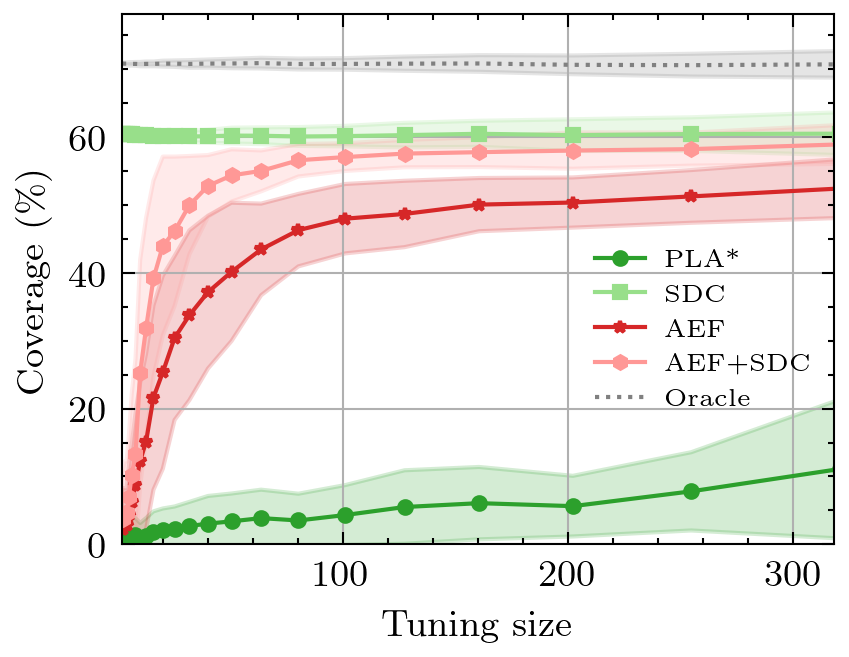

In [ ]:
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)


df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_coverages_mean.columns[5:]):
    plt.plot(tuning_size_arrays*len(y), df_coverages_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_coverages_mean[column] - df_std_dev[column], df_coverages_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.xlabel('Tuning size')
plt.ylabel("Coverage (\%)")
plt.ylim(top=np.max(df_coverages_mean)*1.1, bottom=0)

plt.xlim(left = 2,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
# Add legend above the plot
#plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)
plt.legend(loc='lower right', ncol=1, frameon=False, bbox_to_anchor=(1.0, 0.21))
# Adjust the plot to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust bottom, top, left, right margins

plt.savefig("./graphs/Polyp_PVT_Shuffle_Split_Test_OOD_trainables.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))



PLA@10 mean: 3.86
PLA@10 stdev: 4.19
AEF@10 mean: 43.42
AEF@10 stdev: 6.79
AEF+SDC@10 mean: 55.02
AEF+SDC@10 stdev: 3.02 

PLA@50 mean: 10.97
PLA@50 stdev: 10.07
AEF@50 mean: 52.39
AEF@50 stdev: 4.32
AEF+SDC@50 mean: 58.90
AEF+SDC@50 stdev: 2.85 



AURCS

In [ ]:
df_coverages_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}_OOD.pkl')
df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.10
PLA@10 stdev: 0.00
AEF@10 mean: 0.09
AEF@10 stdev: 0.00
AEF+SDC@10 mean: 0.08
AEF+SDC@10 stdev: 0.00 

PLA@50 mean: 0.10
PLA@50 stdev: 0.00
AEF@50 mean: 0.08
AEF@50 stdev: 0.00
AEF+SDC@50 mean: 0.07
AEF+SDC@50 stdev: 0.00 



# Optic cup - OOD

In [ ]:
task = 'optic_cup'
df_coverages_mean = pd.read_pickle(f'df_coverages_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_coverages_std_final_{task}_OOD.pkl')

data = np.load('./data/optic_cup_ood.npz')

y = data['y']

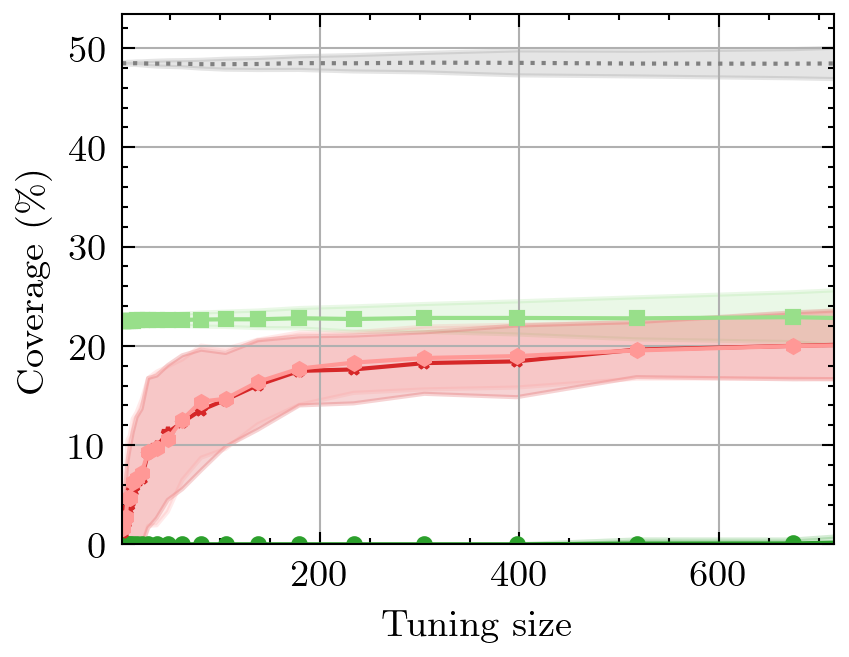

In [ ]:
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_coverages_mean.columns[5:]):
    plt.plot(tuning_size_arrays*len(y), df_coverages_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_coverages_mean[column] - df_std_dev[column], df_coverages_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.xlabel('Tuning size')
plt.ylabel("Coverage (\%)")
plt.ylim(top=np.max(df_coverages_mean)*1.1, bottom=0)

plt.xlim(left = 2,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
# Add legend above the plot
#plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)

# Adjust the plot to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust bottom, top, left, right margins

plt.savefig("./graphs/Optic_Cup_Shuffle_Split_Test_OOD_trainables.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))



PLA@10 mean: 0.00
PLA@10 stdev: 0.00
AEF@10 mean: 16.22
AEF@10 stdev: 4.38
AEF+SDC@10 mean: 16.52
AEF+SDC@10 stdev: 4.19 

PLA@50 mean: 0.17
PLA@50 stdev: 0.61
AEF@50 mean: 20.09
AEF@50 stdev: 3.46
AEF+SDC@50 mean: 20.04
AEF+SDC@50 stdev: 3.41 



AURCS

In [ ]:
df_coverages_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}_OOD.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}_OOD.pkl')
df_coverages_mean.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'Ideal':'Oracle','PLA':'PLA*'},inplace=True)

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.2f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_coverages_mean.iloc[df_coverages_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_coverages_mean.iloc[df_coverages_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.2f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.20
PLA@10 stdev: 0.00
AEF@10 mean: 0.15
AEF@10 stdev: 0.00
AEF+SDC@10 mean: 0.15
AEF+SDC@10 stdev: 0.00 

PLA@50 mean: 0.20
PLA@50 stdev: 0.01
AEF@50 mean: 0.15
AEF@50 stdev: 0.00
AEF+SDC@50 mean: 0.15
AEF+SDC@50 stdev: 0.00 

